# Emotional-Intensity Mismatch in Speaker-Independent SER

This is the **core experiment** of the project. It directly trains and evaluates an RBF-SVM under six emotional-intensity conditions:

- Normal to Normal
- Normal to Strong
- Strong to Strong
- Strong to Normal
- Mixed to Normal
- Mixed to Strong

The public feature table contains 576 RAVDESS speech recordings from 24 actors, restricted to Happy, Sad, and Angry. It contains 31 acoustic features plus actor, emotion, and intensity labels. Raw audio and private file paths are not included.

[Read the full project report](../report/SER_Project_Report.pdf)


## Reproducibility note

This notebook shows two clearly labeled result sets:

1. **Original reported run:** the six Fusion-feature scores archived in `results/intensity_summary.csv` and the final project report.
2. **Fixed public rerun:** a fresh run from the public feature table using an explicit, version-independent five-fold actor partition.

Every fold keeps test actors completely outside the training data. Pitch-extraction failures stored as zero are converted to missing values, then median imputation and standardization are fitted only on each training fold. The original run's exact actor-fold assignment was not archived, so the public rerun is not presented as an exact numerical reproduction. It is a transparent robustness check of the same design and conclusion.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)


## 1. Load and validate the sanitized feature table


In [2]:
candidate_paths = [
    Path("../data/ravdess_intensity_features.csv"),
    Path("data/ravdess_intensity_features.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Place ravdess_intensity_features.csv in the repository's data/ folder."
    )

data = pd.read_csv(data_path).reset_index(drop=True)
summary_candidates = [
    Path("../results/intensity_summary.csv"),
    Path("results/intensity_summary.csv"),
]
summary_path = next((path for path in summary_candidates if path.exists()), None)
if summary_path is None:
    raise FileNotFoundError(
        "Place intensity_summary.csv in the repository's results/ folder."
    )
reported_results = pd.read_csv(summary_path)

feature_columns = [
    "duration", "energy_mean", "energy_std", "pitch_mean", "pitch_std",
] + [
    f"mfcc_{i}_{stat}"
    for i in range(1, 14)
    for stat in ("mean", "std")
]

required_columns = {"actor_id", "emotion", "intensity", *feature_columns}
assert required_columns.issubset(data.columns)
assert len(feature_columns) == 31
assert len(data) == 576
assert data["actor_id"].nunique() == 24
assert set(data["emotion"]) == {"Happy", "Sad", "Angry"}
assert set(data["intensity"]) == {"Normal", "Strong"}
assert set(reported_results["Condition"]) == {
    "Normal_to_Normal", "Normal_to_Strong", "Strong_to_Strong",
    "Strong_to_Normal", "Mixed_to_Normal", "Mixed_to_Strong",
}

duplicate_rows = int(data.duplicated().sum())
pitch_failures = data["pitch_mean"].eq(0)
pitch_failure_count = int(pitch_failures.sum())
data.loc[pitch_failures, ["pitch_mean", "pitch_std"]] = np.nan

print(f"Rows: {len(data)}")
print(f"Actors: {data['actor_id'].nunique()}")
print(f"Acoustic features: {len(feature_columns)}")
print(f"Identical feature rows retained: {duplicate_rows}")
print(f"Pitch failures converted to missing values: {pitch_failure_count}")
display(pd.crosstab(data["emotion"], data["intensity"]))


Rows: 576
Actors: 24
Acoustic features: 31
Identical feature rows retained: 1
Pitch failures converted to missing values: 2


intensity,Normal,Strong
emotion,,
Angry,96,96
Happy,96,96
Sad,96,96


## 2. Define feature groups and experimental conditions


In [3]:
feature_groups = {
    "Pitch": ["pitch_mean", "pitch_std"],
    "Prosody": [
        "duration", "energy_mean", "energy_std", "pitch_mean", "pitch_std"
    ],
    "MFCC": [
        f"mfcc_{i}_{stat}"
        for i in range(1, 14)
        for stat in ("mean", "std")
    ],
    "Fusion": feature_columns,
}

conditions = {
    "Normal_to_Normal": (["Normal"], "Normal"),
    "Normal_to_Strong": (["Normal"], "Strong"),
    "Strong_to_Strong": (["Strong"], "Strong"),
    "Strong_to_Normal": (["Strong"], "Normal"),
    "Mixed_to_Normal": (["Normal", "Strong"], "Normal"),
    "Mixed_to_Strong": (["Normal", "Strong"], "Strong"),
}

emotion_order = ["Happy", "Sad", "Angry"]
test_actor_folds = [
    [3, 9, 10, 11, 18],
    [13, 14, 15, 17, 21],
    [1, 2, 16, 20, 24],
    [4, 7, 19, 22, 23],
    [5, 6, 8, 12],
]

all_actors = sorted(data["actor_id"].unique().tolist())
assert sorted(actor for fold in test_actor_folds for actor in fold) == all_actors

folds = []
for test_actors in test_actor_folds:
    is_test = data["actor_id"].isin(test_actors)
    train_index = data.index[~is_test].to_numpy()
    test_index = data.index[is_test].to_numpy()
    folds.append((train_index, test_index))

for fold_number, (train_index, test_index) in enumerate(folds, start=1):
    train_actors = set(data.iloc[train_index]["actor_id"])
    test_actors = set(data.iloc[test_index]["actor_id"])
    assert train_actors.isdisjoint(test_actors)
    print(
        f"Fold {fold_number}: test actors {sorted(test_actors)}; "
        f"{len(train_actors)} training actors"
    )


Fold 1: test actors [3, 9, 10, 11, 18]; 19 training actors
Fold 2: test actors [13, 14, 15, 17, 21]; 19 training actors
Fold 3: test actors [1, 2, 16, 20, 24]; 19 training actors
Fold 4: test actors [4, 7, 19, 22, 23]; 19 training actors
Fold 5: test actors [5, 6, 8, 12]; 20 training actors


## 3. Train and evaluate one condition


In [4]:
def evaluate_condition(train_intensities, test_intensity, features):
    all_true = []
    all_predicted = []

    for train_index, test_index in folds:
        train_fold = data.iloc[train_index]
        test_fold = data.iloc[test_index]

        train_fold = train_fold[
            train_fold["intensity"].isin(train_intensities)
        ]
        test_fold = test_fold[
            test_fold["intensity"].eq(test_intensity)
        ]

        pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "classifier",
                    SVC(
                        kernel="rbf",
                        C=1.0,
                        gamma="scale",
                        class_weight="balanced",
                    ),
                ),
            ]
        )
        pipeline.fit(train_fold[features], train_fold["emotion"])
        predicted = pipeline.predict(test_fold[features])

        all_true.extend(test_fold["emotion"].tolist())
        all_predicted.extend(predicted.tolist())

    accuracy = accuracy_score(all_true, all_predicted)
    macro_f1 = f1_score(all_true, all_predicted, average="macro")
    recalls = recall_score(
        all_true,
        all_predicted,
        labels=emotion_order,
        average=None,
        zero_division=0,
    )
    matrix = confusion_matrix(all_true, all_predicted, labels=emotion_order)

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "recalls": dict(zip(emotion_order, recalls)),
        "confusion_matrix": matrix,
        "n_predictions": len(all_true),
    }


## 4. Run all feature groups and all six intensity conditions


In [5]:
rows = []
evaluation_details = {}

for feature_group, features in feature_groups.items():
    for condition, (train_intensities, test_intensity) in conditions.items():
        result = evaluate_condition(train_intensities, test_intensity, features)
        evaluation_details[(feature_group, condition)] = result
        rows.append(
            {
                "Feature_Group": feature_group,
                "Condition": condition,
                "Accuracy_%": 100 * result["accuracy"],
                "Macro_F1_%": 100 * result["macro_f1"],
                "Happy_Recall_%": 100 * result["recalls"]["Happy"],
                "Sad_Recall_%": 100 * result["recalls"]["Sad"],
                "Angry_Recall_%": 100 * result["recalls"]["Angry"],
                "Predictions": result["n_predictions"],
            }
        )

results = pd.DataFrame(rows)
macro_f1_table = results.pivot(
    index="Condition", columns="Feature_Group", values="Macro_F1_%"
).loc[list(conditions)]

print("Macro F1 (%)")
display(macro_f1_table.round(2))


Macro F1 (%)


Feature_Group,Fusion,MFCC,Pitch,Prosody
Condition,,,,
Normal_to_Normal,76.66,75.99,42.48,66.80
Normal_to_Strong,46.79,50.60,41.24,42.94
Strong_to_Strong,83.93,82.14,48.93,75.68
Strong_to_Normal,39.27,41.50,39.84,29.47
Mixed_to_Normal,71.77,72.07,43.21,46.72
Mixed_to_Strong,73.44,71.38,49.30,72.19


## 5. Original reported run and fixed public rerun


In [6]:
fusion_results = (
    results[results["Feature_Group"].eq("Fusion")]
    .set_index("Condition")
    .loc[list(conditions)]
    .reset_index()
)
reported_fusion = (
    reported_results[["Condition", "Fusion_Macro_F1_Percent"]]
    .rename(columns={
        "Fusion_Macro_F1_Percent": "Original_Reported_Macro_F1_%"
    })
    .set_index("Condition")
    .loc[list(conditions)]
    .reset_index()
)
comparison = reported_fusion.merge(
    fusion_results[["Condition", "Macro_F1_%"]], on="Condition"
).rename(columns={"Macro_F1_%": "Fixed_Public_Rerun_Macro_F1_%"})
comparison["Difference_pp"] = (
    comparison["Fixed_Public_Rerun_Macro_F1_%"]
    - comparison["Original_Reported_Macro_F1_%"]
)

print("Original archived scores and fixed public rerun")
display(comparison.round(2))

scores = fusion_results.set_index("Condition")["Macro_F1_%"]
matched_mean = scores[["Normal_to_Normal", "Strong_to_Strong"]].mean()
mismatched_mean = scores[["Normal_to_Strong", "Strong_to_Normal"]].mean()
mixed_mean = scores[["Mixed_to_Normal", "Mixed_to_Strong"]].mean()

print(f"Public rerun matched-condition mean: {matched_mean:.2f}%")
print(f"Public rerun mismatched-condition mean: {mismatched_mean:.2f}%")
print(f"Public rerun mixed-training mean: {mixed_mean:.2f}%")
print(f"Public rerun mismatch loss: {matched_mean - mismatched_mean:.2f} points")


Original archived scores and fixed public rerun
Public rerun matched-condition mean: 80.29%
Public rerun mismatched-condition mean: 43.03%
Public rerun mixed-training mean: 72.60%
Public rerun mismatch loss: 37.27 points


,Condition,Original_Reported_Macro_F1_%,Fixed_Public_Rerun_Macro_F1_%,Difference_pp
0,Normal_to_Normal,77.77,76.66,-1.11
1,Normal_to_Strong,45.51,46.79,1.28
2,Strong_to_Strong,80.98,83.93,2.95
3,Strong_to_Normal,39.12,39.27,0.15
4,Mixed_to_Normal,72.60,71.77,-0.83
5,Mixed_to_Strong,73.87,73.44,-0.43


## 6. Visual comparison


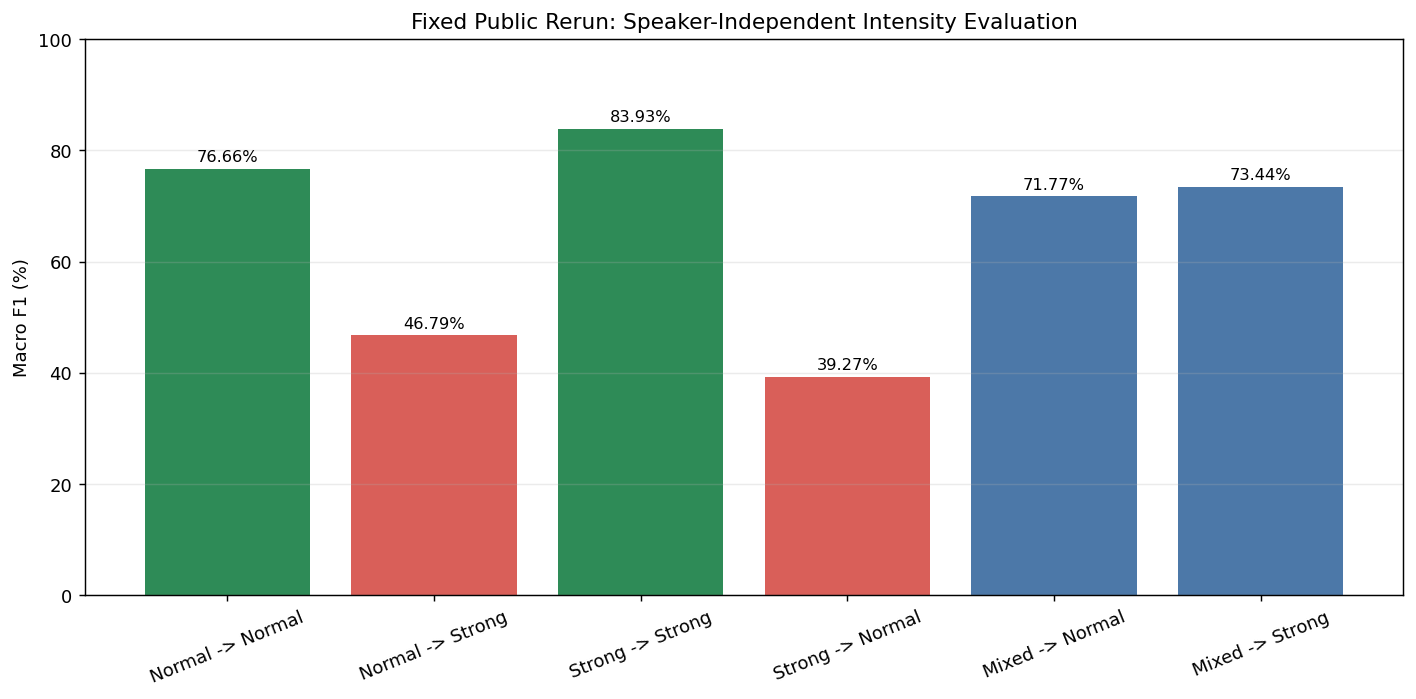

In [7]:
label_map = {
    "Normal_to_Normal": "Normal -> Normal",
    "Normal_to_Strong": "Normal -> Strong",
    "Strong_to_Strong": "Strong -> Strong",
    "Strong_to_Normal": "Strong -> Normal",
    "Mixed_to_Normal": "Mixed -> Normal",
    "Mixed_to_Strong": "Mixed -> Strong",
}
color_map = {
    "Normal_to_Normal": "#2E8B57",
    "Strong_to_Strong": "#2E8B57",
    "Normal_to_Strong": "#D95F59",
    "Strong_to_Normal": "#D95F59",
    "Mixed_to_Normal": "#4C78A8",
    "Mixed_to_Strong": "#4C78A8",
}

plot_data = fusion_results.copy()
plot_data["Label"] = plot_data["Condition"].map(label_map)
colors = plot_data["Condition"].map(color_map)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(plot_data["Label"], plot_data["Macro_F1_%"], color=colors)
ax.set_ylim(0, 100)
ax.set_ylabel("Macro F1 (%)")
ax.set_title("Fixed Public Rerun: Speaker-Independent Intensity Evaluation")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=22)
for bar, value in zip(bars, plot_data["Macro_F1_%"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.3,
        f"{value:.2f}%",
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()


## 7. Directional confusion matrices


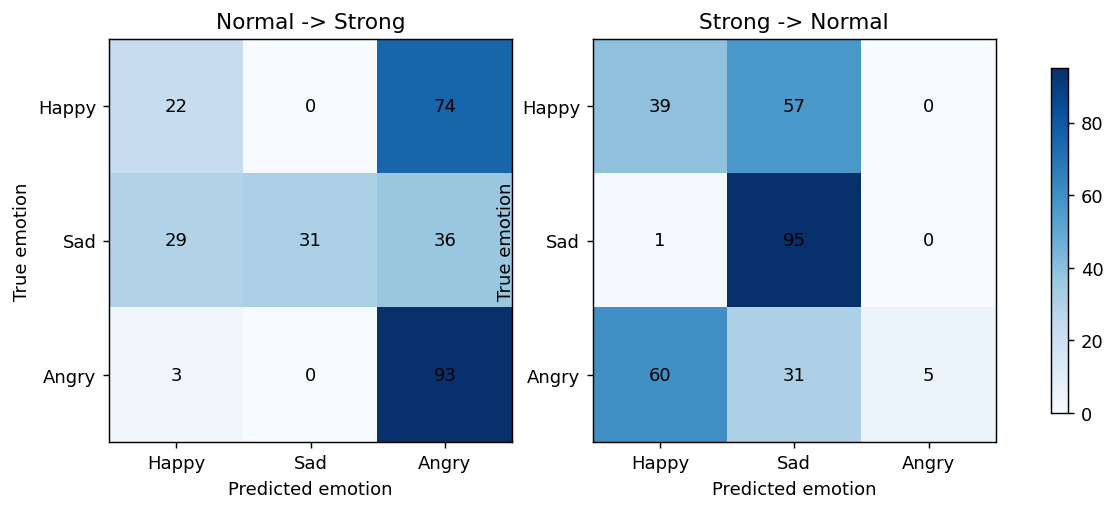

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, condition in zip(axes, ["Normal_to_Strong", "Strong_to_Normal"]):
    matrix = evaluation_details[("Fusion", condition)]["confusion_matrix"]
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(label_map[condition])
    ax.set_xticks(range(len(emotion_order)), emotion_order)
    ax.set_yticks(range(len(emotion_order)), emotion_order)
    ax.set_xlabel("Predicted emotion")
    ax.set_ylabel("True emotion")
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(column, row, matrix[row, column], ha="center", va="center")
fig.colorbar(image, ax=axes, shrink=0.82)
plt.show()


## Interpretation

The original archived run and the fixed public rerun use the same six-condition design but not a claimed-identical actor partition. Small numerical differences are therefore expected. The important conclusion is stable: matched-intensity evaluation is substantially stronger than cross-intensity evaluation, and the two mismatch directions fail differently.

Mixed-intensity training exposes the classifier to a broader acoustic distribution. When its performance is higher than the mismatched conditions, it provides a practical robustness strategy: include multiple expression intensities in training data.

These findings apply to this RAVDESS, handcrafted-feature, RBF-SVM setup. They do not establish that a model can infer a person's true internal emotional state, and they should not automatically be generalized to spontaneous speech or every language.
